PART1: Import Data & Define Data

In [5]:
# Import the loadmat function, which lets Python open .mat files
from scipy.io import loadmat  

# Load the .mat file. This reads everything stored inside the file and puts it into a Python dictionary-like object called "data".
data = loadmat('/home/jovyan/work/__shared/exam_projects/spike_threshold/rawdata01.mat')

# Pull 'd' out of the dictionary.
d = data['d']

# Pull out 'si' and call .item() to "unwrap" it and get a plain Python number (99) instead of a matrix.
si = data['si'].item()

# Print d's shape and si's value, as a quick sanity check that the data loaded correctly.
print(d.shape, si)

(1010101, 2) 99


PART2:To Visualize the Raw Data

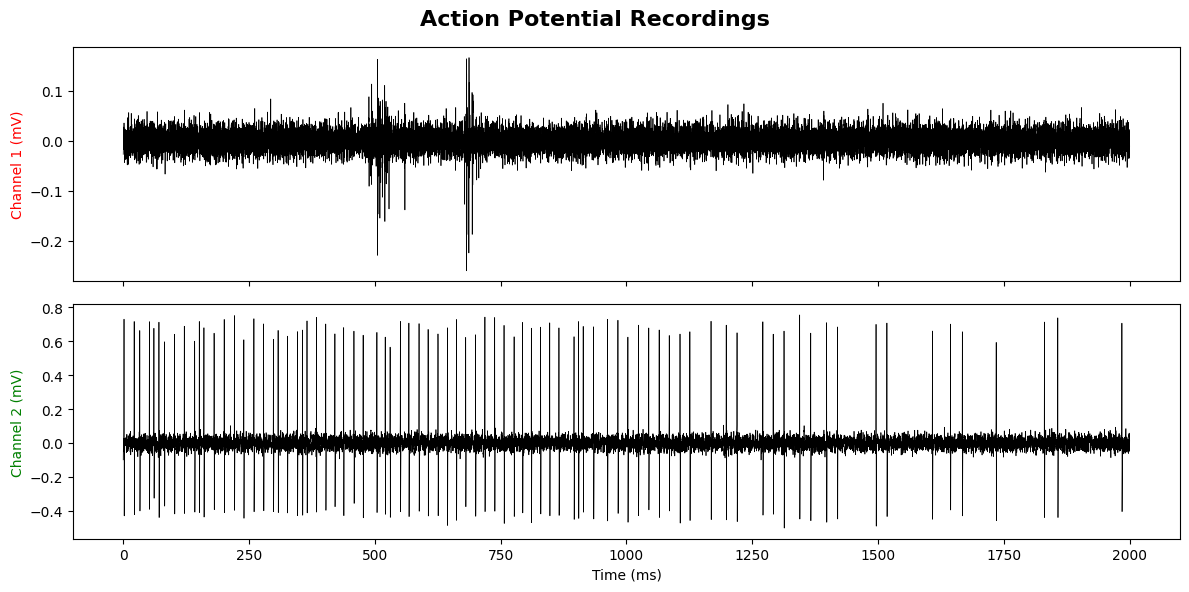

In [3]:
import numpy as np               # NumPy: lets us do fast math on whole arrays of numbers at once
import matplotlib.pyplot as plt  # Matplotlib: the plotting library used to draw the figures

# Convert the sampling interval from microseconds to milliseconds (divide by 1000)
si_ms = si / 1000

# Build a time axis so we can plot the data against real time instead of sample number.
# d.shape[0] = total number of time samples (rows) in the data.
# np.arange(d.shape[0]) creates a list of sample indices: 0, 1, 2, 3, ... up to the last sample.
# Multiplying by si_ms turns each sample index into an actual time value, in milliseconds.
time = np.arange(d.shape[0]) * si_ms

# Create a figure with 2 rows and 1 column of subplots - one plot per recording channel.
# fig = the whole figure/window. axes = the 2 individual plot areas: axes[0] (top), axes[1] (bottom).
# figsize=(12, 6) sets the figure size (width=12, height=6 inches).
# sharex=True makes both subplots share the same x-axis (time), so the same moment in time
# lines up vertically between the two channels - handy for comparing them.
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Boolean mask: True for every time point below 2000 ms (i.e. the first 2 seconds), else False.
# We use this below to only plot the first 2 seconds instead of the whole recording.
mask = time < 2000

# Give the whole figure a title (sits above both subplots).
fig.suptitle('Action Potential Recordings', fontsize=16, fontweight='bold')

# --- Channel 1 (top subplot) ---
# Plot only the masked (first 2s) portion of channel 1 (column 0 of d).
# lw=0.5 makes the line thin; color='black' makes the trace black.
axes[0].plot(time[mask], d[mask, 0], lw=0.5, color='black')
axes[0].set_ylabel('Channel 1 (mV)', color='red')  # label the y-axis for channel 1

# --- Channel 2 (bottom subplot) ---
axes[1].plot(time[mask], d[mask, 1], lw=0.5, color='black')
axes[1].set_ylabel('Channel 2 (mV)', color='green')  # label the y-axis for channel 2

# The two subplots share an x-axis, so we only need to label it once, on the bottom plot.
axes[1].set_xlabel('Time (ms)', color='black')

plt.tight_layout()  # automatically adjust spacing so labels/titles don't overlap
plt.show()          # display the figure


PART3:Threshold Calculation

In [4]:
def auto_threshold(x, k=4):
    '''
    Automatically figure out a good threshold for spike detection, and decide whether it is a positive-going or negative-going spikes.
    x: the signal for one channel
    k: how many "noise units" away from the middle counts as a spike
    '''

    # Find the median (the "middle" value) of the signal. We use the median rather than the
    # mean/average because spikes are rare, large outliers that would pull an average away
    # from the true baseline; the median stays close to the "quiet" baseline even with spikes present.
    median = np.median(x)

    # Measure how far every single data point is from that median (always non-negative,
    # thanks to np.abs), to see how spread out / noisy the signal is.
    distance_from_median = np.abs(x - median)

    # MAD = Median Absolute Deviation. Taking the median of those distances gives a robust estimate of the signal's "noise level".
    mad = np.median(distance_from_median)

    # Convert MAD into an estimate of the noise's standard deviation. 0.6745 is a standard scaling constant that makes MAD comparable to a normal standard deviation, assuming
    # roughly normally-distributed background noise.
    noise = mad / 0.6745

    # Define two candidate thresholds: one above the baseline (catches upward/positive spikes)
    # and one below the baseline (catches downward/negative spikes). k controls how many
    # "noise units" away from baseline we require before calling something a spike.
    pos_thr = median + k * noise
    neg_thr = median - k * noise

    # Count how many data points actually cross each threshold.
    n_pos_thr = np.sum(x > pos_thr)
    n_neg_thr = np.sum(x < neg_thr)

    # Whichever threshold catches more crossings tells us which direction the real spikes
    # go in this channel, so we return that one as the threshold to use going forward.
    if n_neg_thr > n_pos_thr:
        return neg_thr
    else:
        return pos_thr

PART4: Threshold Detection

In [5]:
def spike_detect(d, si, k=4):
    '''
    Detect spikes in multi-channel data. Thresholds are calculated automatically for each channel using auto_threshold.

    d : raw data, one column per channel
    si : sampling interval (as stored in the .mat file, in microseconds)
    k : how many 'noise units' away from baseline counts as a spike
    '''

    si_ms = si/1000           # convert the sampling interval to milliseconds, same as before
    n_samples = d.shape[0]    # total number of time samples (rows) in the data
    n_channels = d.shape[1]   # total number of recording channels (columns) in the data

    # Work out one threshold per channel by running auto_threshold() on each column of d,
    # and collect all of them in a list so we can look each one up by channel number later.
    thresholds = []
    for ch in range(n_channels):
        channel_data = d[:, ch]              # grab just this channel's data (one column)
        thr = auto_threshold(channel_data, k)
        thresholds.append(thr)

    print("Auto thresholds:", thresholds)

    tsl = {}   # "tsl" = time-stamp list. This dictionary will hold, for each channel, the
               # list of times (in ms) at which a spike was detected.

    # Loop through the channels one at a time
    for ch in range(n_channels):
        channel_data = d[:, ch]
        thr = thresholds[ch]
        spike_times = []   # collects the spike times just for this channel

        # Walk through the signal one sample at a time (starting at sample 1, so there is
        # always a previous sample to compare against), checking whether the signal has
        # just "crossed" the threshold between the previous sample and the current one.
        for i in range(1, n_samples):
            previous_value = channel_data[i-1]
            current_value = channel_data[i]

            # If the threshold is positive, a spike is detected when the signal goes from
            # below the threshold to at/above it (an upward crossing).
            if thr >= 0:
                just_crossed = (previous_value < thr) and (current_value >= thr)
            # If the threshold is negative, a spike is detected when the signal goes from
            # above the threshold to at/below it (a downward crossing).
            else:
                just_crossed = (previous_value > thr) and (current_value <= thr)

            if just_crossed:
                spike_time = i * si_ms          # convert the sample index into an actual time
                spike_times.append(spike_time)  # record this spike's time

        tsl[ch] = np.array(spike_times)   # store this channel's spike times as a NumPy array
        print(f"Channel {ch}: {len(spike_times)} spikes detected")

    return tsl, thresholds    # give back both the spike times and the thresholds used


PART5: Plots for Spike Detection

Auto thresholds: [np.float32(-0.07412898), np.float32(-0.10926757)]
Channel 0: 564 spikes detected
Channel 1: 2386 spikes detected


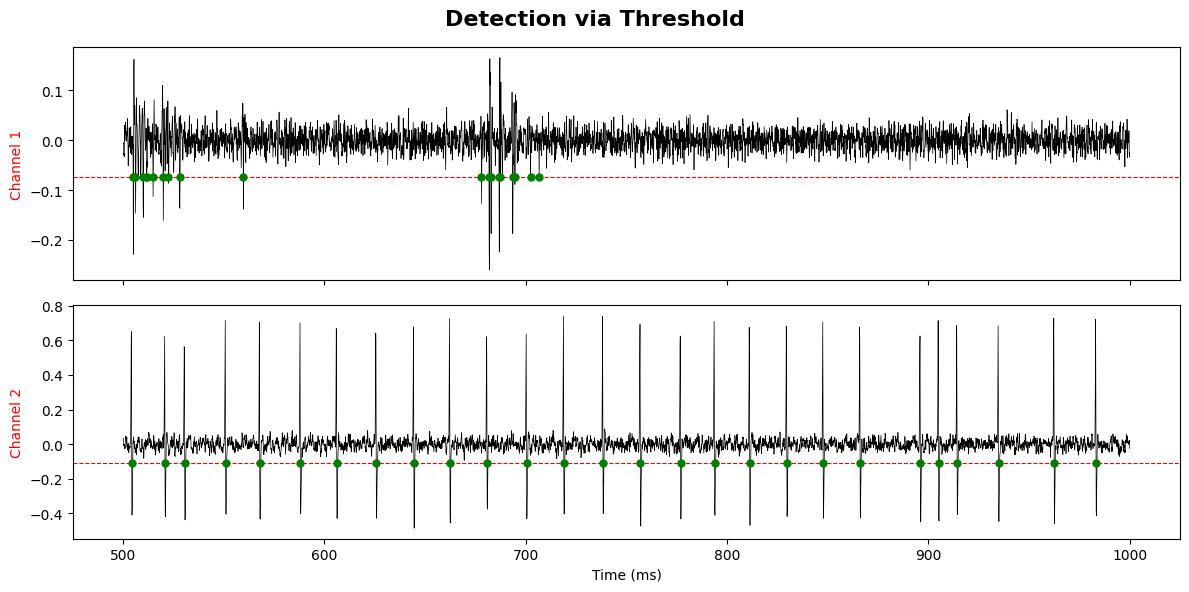

In [13]:
# Run the spike detector on the full dataset. This gives us:
# tsl        - a dictionary of detected spike times, one entry per channel
# thresholds - the threshold value that was used for each channel
tsl, thresholds = spike_detect(d, si, k=4)

# Create a new figure.
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Zoom in on a shorter, 500 ms window (from 500 ms to 1000 ms) so individual spikes and threshold crossings are easy to see.
mask = (time > 500) & (time < 1000)
fig.suptitle('Detection via Threshold', fontsize=16, fontweight='bold')

n_channels = d.shape[1]
for ch in range(n_channels):
    # Plot the raw signal for this channel, within the zoomed-in time window.
    axes[ch].plot(time[mask], d[mask, ch], lw=0.5, color='black')

    # Draw a horizontal dashed red line showing exactly where the threshold sits, so we
    # can visually check that the detected spikes really do cross it.
    axes[ch].axhline(thresholds[ch], color='r', ls='--', lw=0.8)

    # From all the spike times detected for this channel, keep only the ones that fall
    # inside our current 500-1000 ms viewing window.
    times_in_range = tsl[ch][(tsl[ch] > 500) & (tsl[ch] < 1000)]

    # Mark each detected spike with a green dot, placed right on the threshold line at
    # the exact time it was detected.
    axes[ch].plot(times_in_range, [thresholds[ch]]*len(times_in_range),"go", ms=5)
    axes[ch].set_ylabel(f'Channel {ch + 1}', color='red')

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()


PART6: Time Stamp Generator

In [18]:
# Print out a preview of the detected spike times for each channel, so we can quickly
# check that the results look reasonable.
for ch, times in tsl.items():
    print(f"--- Channel {ch + 1} time stamp list (ms) ---")
    for spike_time in times[:10]:   # only show the first 10 spike times, just for a quick look
        print(f"{spike_time:.1f}")
    print(f"... ({len(times)} total)")   # also show how many spikes were found in total

--- Channel 1 time stamp list (ms) ---
488.5
493.4
505.0
506.1
509.9
511.7
514.9
519.9
522.5
528.1
... (564 total)
--- Channel 2 time stamp list (ms) ---
1.8
22.0
33.2
52.2
61.2
71.2
82.3
102.3
121.7
142.3
... (2386 total)
